In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_excel("Global_Superstore2.xlsx")

In [6]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,28-01-2013,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,05-11-2013,06-11-2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51290 non-null  int64  
 1   Order ID        51290 non-null  object 
 2   Order Date      51290 non-null  object 
 3   Ship Date       51290 non-null  object 
 4   Ship Mode       51290 non-null  object 
 5   Customer ID     51290 non-null  object 
 6   Customer Name   51290 non-null  object 
 7   Segment         51290 non-null  object 
 8   City            51290 non-null  object 
 9   State           51290 non-null  object 
 10  Country         51290 non-null  object 
 11  Postal Code     9994 non-null   float64
 12  Market          51290 non-null  object 
 13  Region          51290 non-null  object 
 14  Product ID      51290 non-null  object 
 15  Category        51290 non-null  object 
 16  Sub-Category    51290 non-null  object 
 17  Product Name    51290 non-null 

In [8]:
df.isnull().sum()

Row ID                0
Order ID              0
Order Date            0
Ship Date             0
Ship Mode             0
Customer ID           0
Customer Name         0
Segment               0
City                  0
State                 0
Country               0
Postal Code       41296
Market                0
Region                0
Product ID            0
Category              0
Sub-Category          0
Product Name          0
Sales                 0
Quantity              0
Discount              0
Profit                0
Shipping Cost         0
Order Priority        0
dtype: int64

In [9]:
df.drop('Postal Code', axis=1, inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51290 non-null  int64  
 1   Order ID        51290 non-null  object 
 2   Order Date      51290 non-null  object 
 3   Ship Date       51290 non-null  object 
 4   Ship Mode       51290 non-null  object 
 5   Customer ID     51290 non-null  object 
 6   Customer Name   51290 non-null  object 
 7   Segment         51290 non-null  object 
 8   City            51290 non-null  object 
 9   State           51290 non-null  object 
 10  Country         51290 non-null  object 
 11  Market          51290 non-null  object 
 12  Region          51290 non-null  object 
 13  Product ID      51290 non-null  object 
 14  Category        51290 non-null  object 
 15  Sub-Category    51290 non-null  object 
 16  Product Name    51290 non-null  object 
 17  Sales           51290 non-null 

In [10]:
top_countries = df.groupby('Country')['Sales'].sum().sort_values(ascending=False).head(10)

print(top_countries)

Country
United States     2.297201e+06
Australia         9.252359e+05
France            8.589311e+05
China             7.005620e+05
Germany           6.288400e+05
Mexico            6.225906e+05
India             5.896501e+05
United Kingdom    5.285763e+05
Indonesia         4.048875e+05
Brazil            3.611064e+05
Name: Sales, dtype: float64


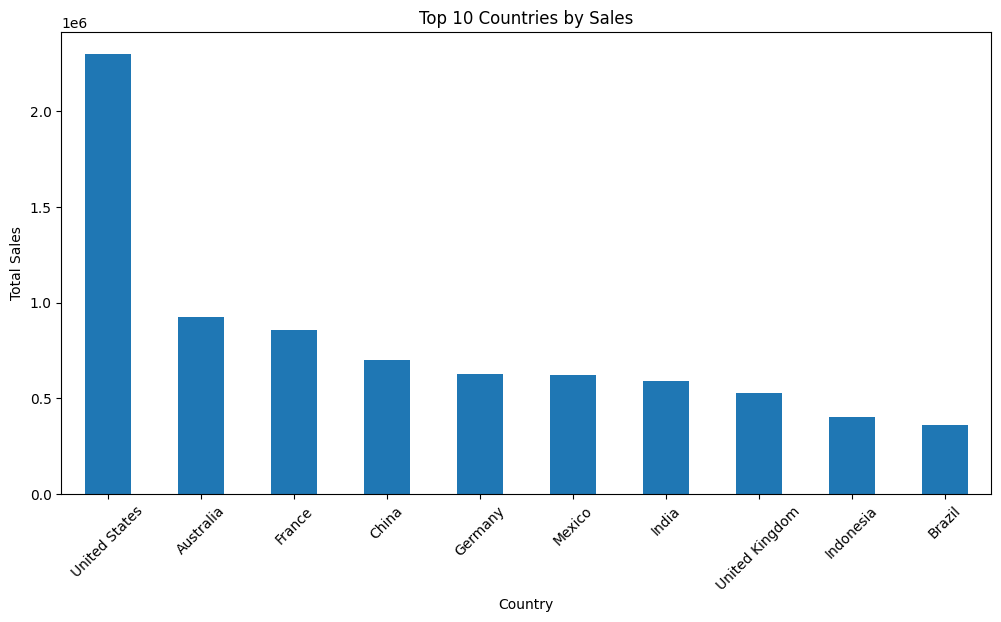

In [11]:
plt.figure(figsize=(12,6))

top_countries.plot(kind='bar')

plt.title("Top 10 Countries by Sales")
plt.xlabel("Country")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.show()

In [12]:
top_profit_regions = df.groupby('Region')['Profit'].sum().sort_values(ascending=False).head(10)

print(top_profit_regions)

Region
Central         311403.98164
North           194597.95252
North Asia      165578.42100
South           140355.76618
Central Asia    132480.18700
Oceania         120089.11200
West            108418.44890
East             91522.78000
Africa           88871.63100
EMEA             43897.97100
Name: Profit, dtype: float64


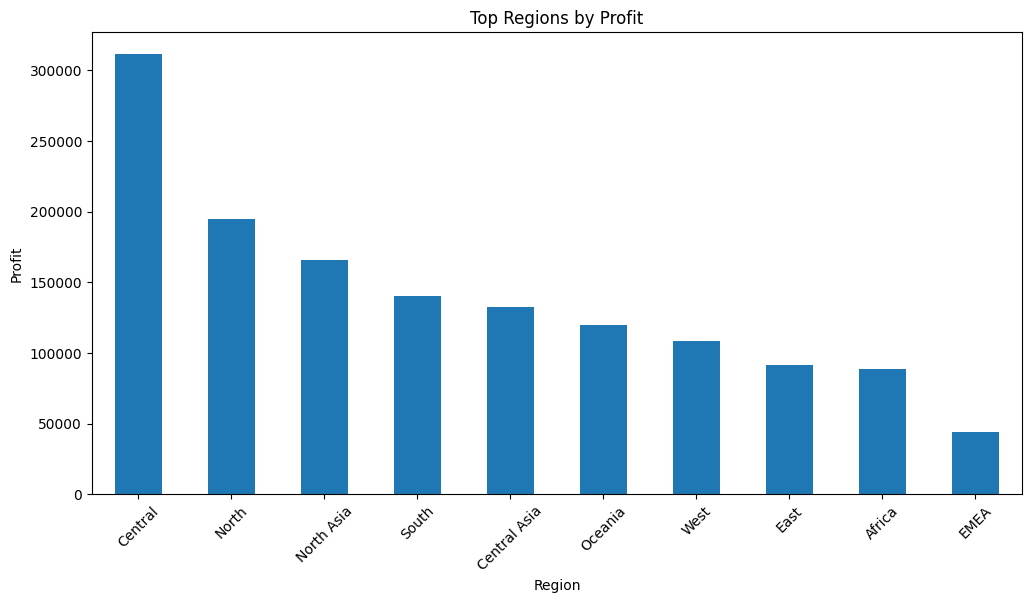

In [13]:
plt.figure(figsize=(12,6))

top_profit_regions.plot(kind='bar')

plt.title("Top Regions by Profit")
plt.xlabel("Region")
plt.ylabel("Profit")

plt.xticks(rotation=45)

plt.show()

In [14]:
region_analysis = df.groupby('Region')[['Sales', 'Profit']].sum()

print(region_analysis.sort_values(by='Sales', ascending=False).head(10))

                       Sales        Profit
Region                                    
Central         2.822303e+06  311403.98164
South           1.600907e+06  140355.76618
North           1.248166e+06  194597.95252
Oceania         1.100185e+06  120089.11200
Southeast Asia  8.844232e+05   17852.32900
North Asia      8.483098e+05  165578.42100
EMEA            8.061613e+05   43897.97100
Africa          7.837732e+05   88871.63100
Central Asia    7.528266e+05  132480.18700
West            7.254578e+05  108418.44890


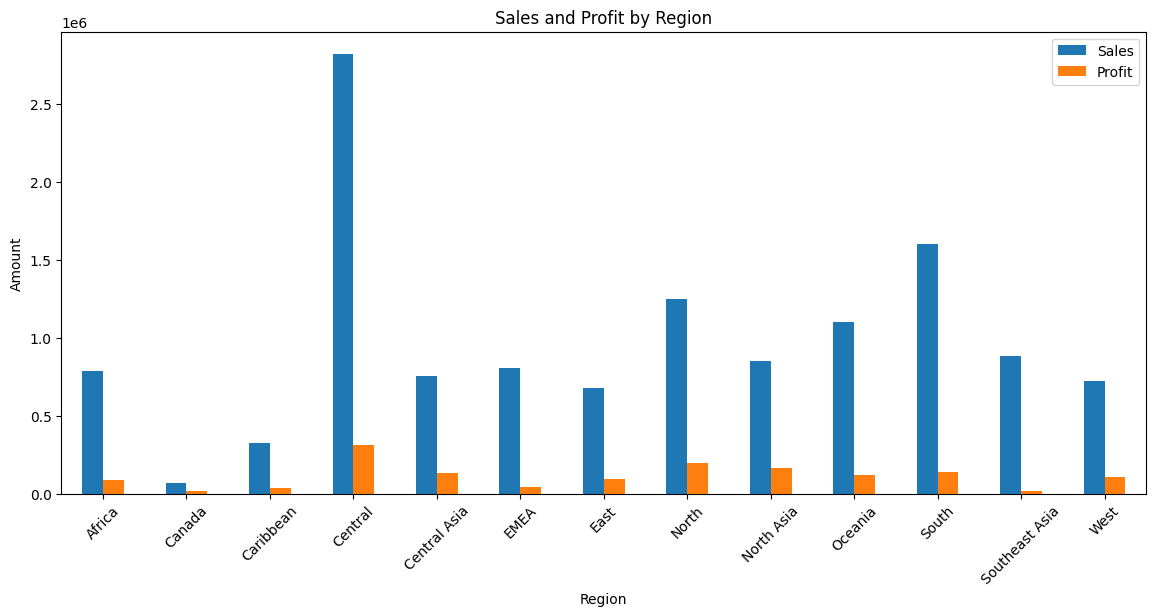

In [15]:
region_analysis.plot(kind='bar', figsize=(14,6))

plt.title("Sales and Profit by Region")
plt.xlabel("Region")
plt.ylabel("Amount")

plt.xticks(rotation=45)

plt.show()

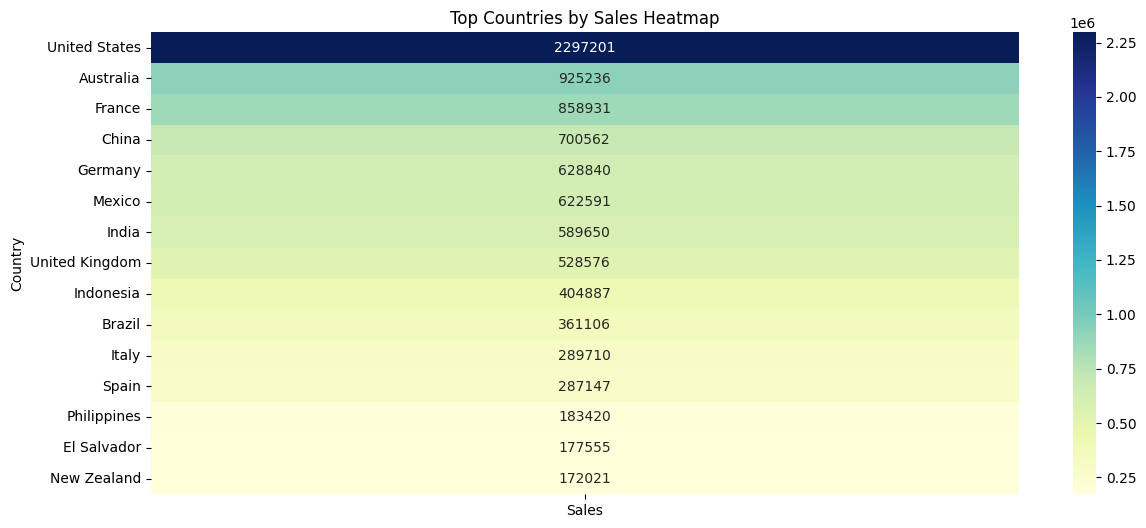

In [16]:
country_sales = df.groupby('Country')['Sales'].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(14,6))

sns.heatmap(country_sales.to_frame(), annot=True, fmt='.0f', cmap='YlGnBu')

plt.title("Top Countries by Sales Heatmap")

plt.show()

In [ ]:
# Business Expansion Insights

The geospatial sales analysis revealed several regions with strong market demand and expansion potential.

## Key Findings

### High Sales Markets
- United States generated the highest total sales.
- Australia, France, and China also showed strong market demand.
- Emerging markets such as India and Brazil demonstrated significant growth potential.

### High Profit Regions
- Central region produced the highest profitability.
- North and North Asia showed strong business performance.
- Oceania demonstrated balanced sales and profit growth.

### Expansion Opportunity Regions
Some regions showed high sales but relatively lower profit margins:
- Southeast Asia
- EMEA
- Africa

These regions may represent:
- underserved markets
- operational inefficiencies
- opportunities for strategic expansion

## Recommendations
- Increase business presence in high-demand regions.
- Optimize pricing and logistics in low-profit regions.
- Expand marketing efforts in emerging markets.
- Improve operational efficiency in Southeast Asia and EMEA.

In [ ]:
# Conclusion

This project analyzed global sales and geographic business performance using geospatial data analysis techniques.

## Major Findings
- The United States was the strongest sales market.
- Several regions demonstrated high profitability and expansion potential.
- Some high-sales regions experienced lower profit margins, indicating opportunities for operational improvement.
- Geographic sales analysis helped identify strategic areas for future business expansion.

## Business Value
Geospatial analytics enables organizations to:
- identify profitable markets
- optimize regional strategies
- improve logistics planning
- support data-driven expansion decisions

The project demonstrated how location-based analytics can support strategic business growth and market expansion planning.